In [1]:
#pip install tifffile

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster
from pathlib import Path
from osgeo import ogr, gdal
import matplotlib.pyplot as plt
import tifffile as tiff
from torch.utils.data import TensorDataset, Dataset, DataLoader
from sklearn.cluster import KMeans
import torch.nn.functional as F

In [3]:
def apply_mask(image):
    mask_norm = np.all((image >= 0) & (image <= 1), axis=2)
    mask_zero = np.all(image == 0, axis=2)
    image[(~mask_norm) | (mask_zero)] = np.nan
    image = reshape_as_raster(image)
    return image

print("test")
image_path = r'C:\Users\arman\Desktop\INSA Toulouse\5A\PIR\PIR-Rio-Tinto\INSA_Crop_EnMAP.tif'

with rio.open(image_path) as src:
    cube = src.read()  # shape = (BANDS, H, W)

l, m, n = cube.shape # check the size of the image 

print(cube.shape)
# 1️⃣ On met en forme : chaque pixel devient une ligne
X = cube.reshape(l, -1).T
print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))

# 2️⃣ Centrage et réduction sur les bandes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_for_show = np.clip(X_scaled, 0, 1)

# 3️⃣ Conversion en tenseur PyTorch
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
print(X_scaled.shape)
"""
print(X_scaled.shape)

# cube : shape = (H, W, BANDS)
cube_min = cube.min(axis=(1,2), keepdims=True)  # min par bande
cube_max = cube.max(axis=(1,2), keepdims=True)  # max par bande

cube_norm = (cube - cube_min) / (cube_max - cube_min + 1e-8)  # ajouter epsilon pour éviter division par 0

cube_norm =  torch.tensor(cube_norm, dtype=torch.float32)

print(cube_norm.shape)
"""

test
(224, 304, 393)
Size of the image is 224x304x393
(119472, 224)


'\nprint(X_scaled.shape)\n\n# cube : shape = (H, W, BANDS)\ncube_min = cube.min(axis=(1,2), keepdims=True)  # min par bande\ncube_max = cube.max(axis=(1,2), keepdims=True)  # max par bande\n\ncube_norm = (cube - cube_min) / (cube_max - cube_min + 1e-8)  # ajouter epsilon pour éviter division par 0\n\ncube_norm =  torch.tensor(cube_norm, dtype=torch.float32)\n\nprint(cube_norm.shape)\n'

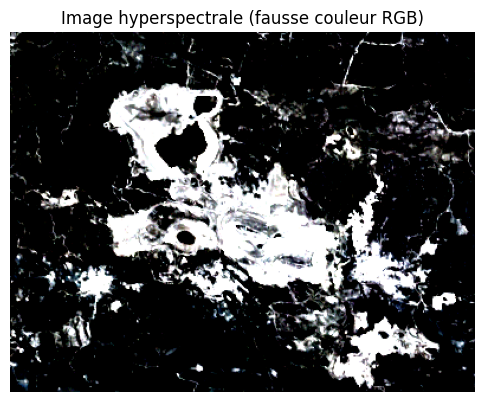

In [4]:
import numpy as np
import rasterio

"""
with rasterio.open(image_path) as src:
    cube = src.read()  # shape = (BANDS, H, W)
    print(cube.shape)
    cube = np.transpose(cube, (1, 2, 0))  # → (H, W, BANDS)
"""

# Choisir 3 bandes pour RGB
r_band = 0   # index de la bande rouge
g_band = 1  # index de la bande verte
b_band = 2    # index de la bande bleue

rgb_plot = (X_scaled_for_show.T).reshape(l, m, n)
rgb_image = np.stack([
    rgb_plot[r_band, :, :],
    rgb_plot[g_band, :, :],
    rgb_plot[b_band, :, :]
], axis=2)  # shape = (H, W, 3)
# Créer une image RGB

# Afficher
plt.figure(figsize=(6,6))
plt.imshow(rgb_image)
plt.title("Image hyperspectrale (fausse couleur RGB)")
plt.axis('off')
plt.show()


In [5]:
# On essaie d'abord sans ACP
"""
# 3️⃣ PCA (par exemple 95 % de variance expliquée)
pca = PCA(n_components=0.999)
X_pca = pca.fit_transform(X_scaled)

# 4️⃣ On peut reformer l'image PCA (même taille spatiale)
nb_comp = X_pca.shape[1]
print(X_pca.shape)
image_pca = X_pca.reshape(m, n, nb_comp)

print(image_pca.shape)
print("Variance expliquée : ", np.sum(pca.explained_variance_ratio_))
print(nb_comp)
"""
X_entry = X_tensor.reshape(n, m, l)

In [6]:
"""

import torch.nn.functional as F

def make_square(image_tensor):
    # image_tensor: (C, H, W)
    C, H, W = image_tensor.shape
    size = max(H, W)
    # padding : (left, right, top, bottom)
    pad_left = (size - W) // 2
    pad_right = size - W - pad_left
    pad_top = (size - H) // 2
    pad_bottom = size - H - pad_top
    image_tensor = F.pad(image_tensor, (pad_left, pad_right, pad_top, pad_bottom))
    return image_tensor

# image: (C, H, W)
image_square = make_square(X_entry.T)
print(image_square.shape)
"""

'\n\nimport torch.nn.functional as F\n\ndef make_square(image_tensor):\n    # image_tensor: (C, H, W)\n    C, H, W = image_tensor.shape\n    size = max(H, W)\n    # padding : (left, right, top, bottom)\n    pad_left = (size - W) // 2\n    pad_right = size - W - pad_left\n    pad_top = (size - H) // 2\n    pad_bottom = size - H - pad_top\n    image_tensor = F.pad(image_tensor, (pad_left, pad_right, pad_top, pad_bottom))\n    return image_tensor\n\n# image: (C, H, W)\nimage_square = make_square(X_entry.T)\nprint(image_square.shape)\n'

In [7]:
class SpectralConvAE(nn.Module):
    def __init__(self, bands, latent_dim):
        super().__init__()

        # Encodeur 1D
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * bands, latent_dim)
        )
        
        # Décodeur
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 32 * bands),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 1, kernel_size=5, padding=2),
            nn.Sigmoid()
        )

        self.bands = bands

    def forward(self, x):
        # x : (batch, bands)
        x = x.unsqueeze(1)                  # → (batch, 1, bands)
        z = self.encoder(x)
        x = self.decoder_fc(z)
        x = x.view(-1, 32, self.bands)
        x = self.decoder_conv(x)
        return x.squeeze(1), z

In [8]:
class LinearAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super().__init__()

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, in_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [9]:
def train_autoencoder(model, dataloader, epochs, criterion, optimizer, device):
    for ep in range(epochs):
        model.train()
        loss_sum = 0
        for x, in dataloader:
            x = x.to(device)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{epochs}   Loss = {loss_sum/len(dataloader):.6f}")

In [10]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [11]:
import matplotlib.colors as mcolors

def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return mcolors.ListedColormap(colors)

In [ ]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

Epoch 1/5   Loss = 0.604490
Epoch 2/5   Loss = 0.572229
Epoch 3/5   Loss = 0.570528
Epoch 4/5   Loss = 0.569915
Epoch 5/5   Loss = 0.569589


C:\Users\arman\AppData\Local\Temp\ipykernel_7012\3351488288.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.


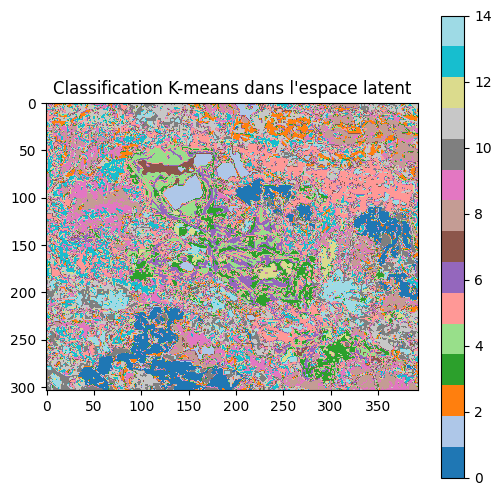

In [13]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 16               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters = 15
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    classification_map = labels_1d.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()

In [14]:

class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, input_size=128):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, 2, 1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, 2, 1),          # H/8
            nn.ReLU(True),

            nn.Conv2d(128, 256, 3, 2, 1),         # H/16
            nn.ReLU(True),
        )

        # Calculer la taille du tenseur après convolutions
        conv_out_size = 256 * (input_size // 16) * (input_size // 16)

        # ------- LATENT VECTOR -------
        self.fc_enc = nn.Linear(conv_out_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, conv_out_size)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, 2, 1, 1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),    # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3, 2, 1, 1),  # H*2
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        batch_size = z.size(0)
        z = z.view(batch_size, -1)        # Flatten
        z = self.fc_enc(z)                # Latent vector

        # Decoder
        z = self.fc_dec(z)
        z = z.view(batch_size, 256, x.size(2)//16, x.size(3)//16)  # reshape pour decoder
        x_recon = self.decoder_conv(z)
        return x_recon


In [15]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 16               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 5
    dataset = PatchDataset(X_tensor.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for  batch_idx, (x, _) in enumerate(loader_ordered):
            x = x.to(DEVICE)

            out = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader_ordered):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters = 15
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    classification_map = labels_1d.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()

ValueError: too many values to unpack (expected 2)